[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/22%20-%20Association%20models%20using%20Apriori/Association_models_using_Apriori.ipynb)

# Overview

Links

*   [association rule learning](https://en.wikipedia.org/wiki/Association_rule_learning)
*   [Apriori algorithm](https://en.wikipedia.org/wiki/Apriori_algorithm)


---

We'll be using 

1.   `mlxtend` which package provides an [implementation of Apriori](http://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/) ([source code](https://github.com/rasbt/mlxtend/blob/master/mlxtend/frequent_patterns/apriori.py))
2.   `networkx` package for visualizations – [tutorial for drawing a directed graph](https://networkx.github.io/documentation/networkx-1.10/tutorial/index.html).

# Data
The dataset we'll be using is from the UCI Machine Learning Repository and represents transactional data from a UK retailer from 2010 through 2011
[http://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx](http://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx)

In [0]:
!pip install MLxtend xlrd

    100% |████████████████████████████████| 112kB 4.3MB/s 


In [0]:
import numpy as np
import pandas as pd

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import OnehotTransactions, TransactionEncoder

In [0]:
df = pd.read_excel('http://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [0]:
df.shape

(541909, 8)

In [0]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [0]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


**`Description` we absolutely need, so we have to drop the missing ones – but seems like `CustomerID` could just be a random number and it woulnd't hurt our analysis if we fill the missing values in some fashion**

In [0]:
df.dropna(subset=['Description'], how='any', inplace=True)

In [0]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64


Let's pick a random value to fill in the missing values of `CustomerID`

In [0]:
df['CustomerID'].describe()

count    406829.000000
mean      15287.690570
std        1713.600303
min       12346.000000
25%       13953.000000
50%       15152.000000
75%       16791.000000
max       18287.000000
Name: CustomerID, dtype: float64

In [0]:
import random

min_cust_id = int(df['CustomerID'].min())
max_cust_id = int(df['CustomerID'].max())
df['CustomerID'] = df['CustomerID'].apply(lambda val: val if not np.isnan(val) else random.uniform(min_cust_id, max_cust_id))

In [0]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [0]:
df.shape

(540455, 8)

In [0]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

**`InvoiceNo` will act as our uniqueID – and it should be converted to an integer**

In [0]:
df['InvoiceNo'] = df['InvoiceNo'].apply(pd.to_numeric, errors='coerce')
print(df.isnull().sum())

InvoiceNo      9291
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64


In [0]:
df.dropna(subset=['InvoiceNo'], how='any', inplace=True)

Convert `InvoiceNo` to int

In [0]:
df['InvoiceNo'] = df['InvoiceNo'].astype('int')

In [0]:
df.shape

(531164, 8)

In [0]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [0]:
df.dtypes

InvoiceNo               int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

**`Descriptions` has a value of 'POSTAGE' in it – we will drop those since it could negatively skew/impact the results**

In [0]:
df = df[df['Description']!='POSTAGE']

In [0]:
df.shape

(530038, 8)

# Analysis (per country)

Let's start with `Germany` as an example

**Build the dataframe we need for the Apriori Algorithm – `Quantity` by `Description` **

In [0]:
dataset = df[df['Country']=='Germany'].pivot_table(index='InvoiceNo', 
                                                   columns='Description', 
                                                   values='Quantity', 
                                                   aggfunc='sum', 
                                                   fill_value=0)
dataset.head()

Description,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,...,YULETIDE IMAGES GIFT WRAP SET,ZINC HEART T-LIGHT HOLDER,ZINC STAR T-LIGHT HOLDER,ZINC BOX SIGN HOME,ZINC FOLKART SLEIGH BELLS,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536527,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536840,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536861,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536967,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536983,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**We only want 0 or 1 for the 'Quantity', as we are only concerned with whether a transaction includes an item or not (not the actual quantity per transaction)**

In [0]:
dataset = dataset.applymap(lambda quantity: 1 if quantity > 0 else 0)
dataset.head()

Description,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,...,YULETIDE IMAGES GIFT WRAP SET,ZINC HEART T-LIGHT HOLDER,ZINC STAR T-LIGHT HOLDER,ZINC BOX SIGN HOME,ZINC FOLKART SLEIGH BELLS,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536527,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536840,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536861,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536967,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536983,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Apriori Algorithm

In [0]:
frequent_itemsets = apriori(dataset, min_support=0.05, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.104677,[6 RIBBONS RUSTIC CHARM]
1,0.071269,[ALARM CLOCK BAKELIKE PINK]
2,0.066815,[CHARLOTTE BAG APPLES DESIGN]
3,0.051225,[CHILDRENS CUTLERY DOLLY GIRL ]
4,0.062361,[COFFEE MUG APPLES DESIGN]
5,0.064588,[FAWN BLUE HOT WATER BOTTLE]
6,0.073497,[GUMBALL COAT RACK]
7,0.057906,[IVORY KITCHEN SCALES]
8,0.064588,[JAM JAR WITH PINK LID]
9,0.093541,[JAM MAKING SET PRINTED]


In [0]:
high_confidence = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.08)
high_confidence

,antecedants,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(PLASTERS IN TIN CIRCUS PARADE ),(PLASTERS IN TIN WOODLAND ANIMALS),0.118040,0.140312,0.069042,0.584906,4.168613,0.052480,2.071067
1,(PLASTERS IN TIN WOODLAND ANIMALS),(PLASTERS IN TIN CIRCUS PARADE ),0.140312,0.118040,0.069042,0.492063,4.168613,0.052480,1.736359
2,(ROUND SNACK BOXES SET OF 4 FRUITS ),(PLASTERS IN TIN CIRCUS PARADE ),0.160356,0.118040,0.051225,0.319444,2.706237,0.032296,1.295941
3,(PLASTERS IN TIN CIRCUS PARADE ),(ROUND SNACK BOXES SET OF 4 FRUITS ),0.118040,0.160356,0.051225,0.433962,2.706237,0.032296,1.483370
4,(ROUND SNACK BOXES SET OF4 WOODLAND ),(PLASTERS IN TIN CIRCUS PARADE ),0.249443,0.118040,0.057906,0.232143,1.966644,0.028462,1.148599
5,(PLASTERS IN TIN CIRCUS PARADE ),(ROUND SNACK BOXES SET OF4 WOODLAND ),0.118040,0.249443,0.057906,0.490566,1.966644,0.028462,1.473315
6,(PLASTERS IN TIN WOODLAND ANIMALS),(PLASTERS IN TIN SPACEBOY),0.140312,0.109131,0.062361,0.444444,4.072562,0.047048,1.603563
7,(PLASTERS IN TIN SPACEBOY),(PLASTERS IN TIN WOODLAND ANIMALS),0.109131,0.140312,0.062361,0.571429,4.072562,0.047048,2.005939
8,(ROUND SNACK BOXES SET OF4 WOODLAND ),(PLASTERS IN TIN WOODLAND ANIMALS),0.249443,0.140312,0.075724,0.303571,2.163549,0.040724,1.234424
9,(PLASTERS IN TIN WOODLAND ANIMALS),(ROUND SNACK BOXES SET OF4 WOODLAND ),0.140312,0.249443,0.075724,0.539683,2.163549,0.040724,1.630520


In [0]:
high_lift = association_rules(frequent_itemsets, metric='lift', min_threshold=4)
high_lift

,antecedants,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(PLASTERS IN TIN CIRCUS PARADE ),(PLASTERS IN TIN WOODLAND ANIMALS),0.118040,0.140312,0.069042,0.584906,4.168613,0.052480,2.071067
1,(PLASTERS IN TIN WOODLAND ANIMALS),(PLASTERS IN TIN CIRCUS PARADE ),0.140312,0.118040,0.069042,0.492063,4.168613,0.052480,1.736359
2,(PLASTERS IN TIN WOODLAND ANIMALS),(PLASTERS IN TIN SPACEBOY),0.140312,0.109131,0.062361,0.444444,4.072562,0.047048,1.603563
3,(PLASTERS IN TIN SPACEBOY),(PLASTERS IN TIN WOODLAND ANIMALS),0.109131,0.140312,0.062361,0.571429,4.072562,0.047048,2.005939
4,(RED RETROSPOT CHARLOTTE BAG),(WOODLAND CHARLOTTE BAG),0.071269,0.129176,0.060134,0.843750,6.531789,0.050927,5.573274
5,(WOODLAND CHARLOTTE BAG),(RED RETROSPOT CHARLOTTE BAG),0.129176,0.071269,0.060134,0.465517,6.531789,0.050927,1.737625


**Create a function for the above steps – given a 'Country', it returns the `strong_association_rules`**

In [0]:
def find_associations(country):
  dataset = df[df['Country']==country].pivot_table(index='InvoiceNo', 
                                                   columns='Description', 
                                                   values='Quantity', 
                                                   aggfunc='sum', 
                                                   fill_value=0)
  
  dataset = dataset.applymap(lambda quantity: 1 if quantity>0 else 0)  
  
  frequent_itemsets = apriori(dataset, min_support=0.05, use_colnames=True)
  rules = association_rules(frequent_itemsets, metric='lift', min_threshold=4)
  
  return rules  

In [0]:
rules = find_associations('Germany')
rules

,antecedants,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(PLASTERS IN TIN WOODLAND ANIMALS),(PLASTERS IN TIN CIRCUS PARADE ),0.140312,0.118040,0.069042,0.492063,4.168613,0.052480,1.736359
1,(PLASTERS IN TIN CIRCUS PARADE ),(PLASTERS IN TIN WOODLAND ANIMALS),0.118040,0.140312,0.069042,0.584906,4.168613,0.052480,2.071067
2,(PLASTERS IN TIN WOODLAND ANIMALS),(PLASTERS IN TIN SPACEBOY),0.140312,0.109131,0.062361,0.444444,4.072562,0.047048,1.603563
3,(PLASTERS IN TIN SPACEBOY),(PLASTERS IN TIN WOODLAND ANIMALS),0.109131,0.140312,0.062361,0.571429,4.072562,0.047048,2.005939
4,(WOODLAND CHARLOTTE BAG),(RED RETROSPOT CHARLOTTE BAG),0.129176,0.071269,0.060134,0.465517,6.531789,0.050927,1.737625
5,(RED RETROSPOT CHARLOTTE BAG),(WOODLAND CHARLOTTE BAG),0.071269,0.129176,0.060134,0.843750,6.531789,0.050927,5.573274


### Visualization – Directed Graph

In [0]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_association_graph(rules, count, show_labels=True):
  G = nx.DiGraph()
  
  colors = np.random.uniform(0.3, 0.7, count)
  rule_nodes = set()
  
  for i in range(count):
    rule_node = 'R' + str(i)
    G.add_nodes_from([rule_node])
    rule_nodes.add(rule_node)
    
    weight = rules.iloc[i]['lift']
    edge_color = colors[i]
    
    for antecedant in rules.iloc[i]['antecedants']:
      G.add_nodes_from([antecedant])
      G.add_edge(antecedant, rule_node, color=edge_color, weight=weight)
      
    for consequent in rules.iloc[i]['consequents']:      
      G.add_edge(rule_node, consequent, color=edge_color, weight=weight)
  
  # rule nodes should be yellow, other nodes should be green
  node_colors = ['#FFFF00' if node in rule_nodes else '#98FB98' for node in G]
  
  options = {
      'node_size': 1000,
      'arrowstyle': '-|>',
      'arrowsize': 20,
      'font_size': 16
  }
  
  nodes = G.nodes()
  edges = G.edges()  
  edge_colors = [G[src][dest]['color'] for src, dest in edges]
  edge_weights = [G[src][dest]['weight'] for src, dest in edges]
  
  positions = nx.spring_layout(G, k=15, scale=1)
  nx.draw_networkx(G, 
                   positions, 
                   edges=edges, 
                   edge_color=edge_colors,
                   width=edge_weights,
                   node_color=node_colors, 
                   with_labels=False, 
                   arrows=True,
                   **options)
  
  # labels under the ndodes
  # positions is a map {node => [x_pos, y_pos]}
  if show_labels:
    for each_node in positions:
      positions[each_node][1] -= 0.15  
    nx.draw_networkx_labels(G, positions)
  
  plt.show()

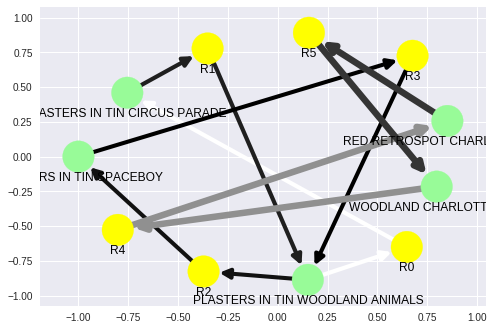

In [0]:
plot_association_graph(rules, len(rules))

### udpate `find_associations()` to include the graph as well – and make it a generic function we can use

In [0]:
def find_associations(country, support_threshold, lift_threshold):
  dataset = df[df['Country']==country].pivot_table(index='InvoiceNo', 
                                                   columns='Description', 
                                                   values='Quantity', 
                                                   aggfunc='sum', 
                                                   fill_value=0)
  
  dataset = dataset.applymap(lambda quantity: 1 if quantity>0 else 0)
  
  frequent_itemsets = apriori(dataset, min_support=support_threshold, use_colnames=True)
  rules = association_rules(frequent_itemsets, metric='lift', min_threshold=lift_threshold)
  
  plot_association_graph(rules, len(rules))
  
  return rules

# Germany

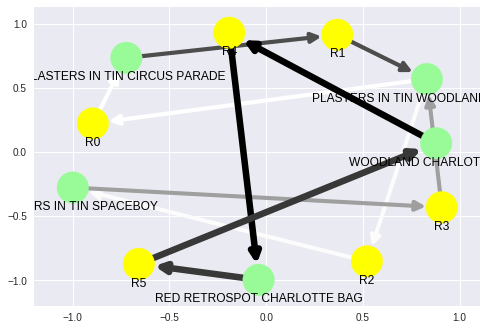

,antecedants,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(PLASTERS IN TIN WOODLAND ANIMALS),(PLASTERS IN TIN CIRCUS PARADE ),0.140312,0.118040,0.069042,0.492063,4.168613,0.052480,1.736359
1,(PLASTERS IN TIN CIRCUS PARADE ),(PLASTERS IN TIN WOODLAND ANIMALS),0.118040,0.140312,0.069042,0.584906,4.168613,0.052480,2.071067
2,(PLASTERS IN TIN WOODLAND ANIMALS),(PLASTERS IN TIN SPACEBOY),0.140312,0.109131,0.062361,0.444444,4.072562,0.047048,1.603563
3,(PLASTERS IN TIN SPACEBOY),(PLASTERS IN TIN WOODLAND ANIMALS),0.109131,0.140312,0.062361,0.571429,4.072562,0.047048,2.005939
4,(WOODLAND CHARLOTTE BAG),(RED RETROSPOT CHARLOTTE BAG),0.129176,0.071269,0.060134,0.465517,6.531789,0.050927,1.737625
5,(RED RETROSPOT CHARLOTTE BAG),(WOODLAND CHARLOTTE BAG),0.071269,0.129176,0.060134,0.843750,6.531789,0.050927,5.573274


In [0]:
find_associations('Germany', support_threshold=0.05, lift_threshold=4)

# Belgium

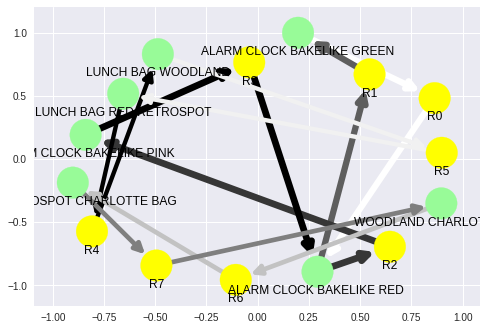

,antecedants,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.122449,0.132653,0.102041,0.833333,6.282051,0.085798,5.204082
1,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.132653,0.122449,0.102041,0.769231,6.282051,0.085798,3.802721
2,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE PINK),0.132653,0.091837,0.081633,0.615385,6.700855,0.069450,2.361224
3,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.091837,0.132653,0.081633,0.888889,6.700855,0.069450,7.806122
4,(LUNCH BAG RED RETROSPOT),(LUNCH BAG WOODLAND),0.122449,0.153061,0.081633,0.666667,4.355556,0.062890,2.540816
5,(LUNCH BAG WOODLAND),(LUNCH BAG RED RETROSPOT),0.153061,0.122449,0.081633,0.533333,4.355556,0.062890,1.880466
6,(WOODLAND CHARLOTTE BAG),(RED RETROSPOT CHARLOTTE BAG),0.122449,0.142857,0.081633,0.666667,4.666667,0.064140,2.571429
7,(RED RETROSPOT CHARLOTTE BAG),(WOODLAND CHARLOTTE BAG),0.142857,0.122449,0.081633,0.571429,4.666667,0.064140,2.047619


In [0]:
find_associations('Belgium', support_threshold=0.08, lift_threshold=4)

**Observation:** 

The association between `'WOODLAND CHARLOTTE BAG'` and `'RED RETROSPOT CHARLOTTE BAG'` does appear in both `Germany` and `Belgium`,  showcasing a potential item pair which could be popular across the entire Europe (and hence important for the Online Retailer)